In [104]:
import pandas as pd
import numpy as np

In [105]:
#with open('../data/neims/spec_files/df_neims_gecko_3_9_22.pkl', 'rb') as file:
#


In [106]:
df_gecko = pd.read_pickle('../data/neims/spec_files/df_neims_gecko_3_9_22.pkl')
df_gecko

,SMILES,spec
0,C=O,"[[14, 202], [15, 313], [16, 165], [18, 16], [1..."
1,O=C[N+](=O)[O-],"[[14, 72], [16, 151], [17, 70], [18, 108], [19..."
2,O=CC(=O)[N+](=O)[O-],"[[14, 153], [15, 174], [16, 125], [17, 36], [1..."
3,O=C(O)C(=O)[N+](=O)[O-],"[[14, 120], [15, 236], [16, 149], [17, 78], [1..."
4,O=C(OO)C(=O)[N+](=O)[O-],"[[14, 136], [15, 268], [16, 152], [17, 62], [1..."
...,...,...
166153,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,"[[14, 70], [15, 145], [16, 82], [17, 31], [18,..."
166154,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 53], [15, 108], [16, 44], [17, 39], [18,..."
166155,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 54], [15, 123], [16, 54], [17, 45], [18,..."
166156,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,"[[14, 60], [15, 69], [16, 69], [26, 44], [27, ..."


In [107]:
df_gecko_labels = pd.read_csv('../data/neims/labels.tsv', sep='\t')
df_gecko_labels 

,Unnamed: 0,dataset,spec,ionization,formula,smiles,inchikey,instrument
0,0,neims,gecko_0,[M]+,CH2O,C=O,WSFSSNUMVMOOMR-UHFFFAOYSA-N,simulated
1,1,neims,gecko_1,[M]+,CHNO3,O=C[N+](=O)[O-],CAMJPMYWRKKZNK-UHFFFAOYSA-N,simulated
2,2,neims,gecko_2,[M]+,C2HNO4,O=CC(=O)[N+](=O)[O-],UJDBJZXDOVXPFV-UHFFFAOYSA-N,simulated
3,3,neims,gecko_3,[M]+,C2HNO5,O=C(O)C(=O)[N+](=O)[O-],RMULBIRLFFXIEL-UHFFFAOYSA-N,simulated
4,4,neims,gecko_4,[M]+,C2HNO6,O=C(OO)C(=O)[N+](=O)[O-],NVYYGCURLZHQKD-UHFFFAOYSA-N,simulated
...,...,...,...,...,...,...,...,...
166153,166153,neims,gecko_166429,[M]+,C7H8N2O15,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,WYENNZRRQBYCFU-UHFFFAOYSA-N,simulated
166154,166154,neims,gecko_166430,[M]+,C7H9NO11,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],FBQPUINTQICKCK-UHFFFAOYSA-N,simulated
166155,166155,neims,gecko_166431,[M]+,C7H7NO11,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],UUQCECUWJAPTDH-UHFFFAOYSA-N,simulated
166156,166156,neims,gecko_166432,[M]+,C6H6N2O14,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,QWVMJYNPWAQOLN-UHFFFAOYSA-N,simulated


In [108]:
df_gecko_split = pd.read_csv('../data/neims/split.tsv', sep='\t')
df_gecko_split['split'] = df_gecko_split['split'].apply(lambda x: x if x =='train' or x== 'val' else 'train')
df_gecko_split['split'].value_counts()

train    155918
val       10240
Name: split, dtype: int64

In [109]:
df_gecko_merged = pd.merge(left=df_gecko, right=df_gecko_labels, left_on='SMILES', right_on='smiles')
df_gecko_merged['name'] = df_gecko_merged['spec_y']
df_gecko_merged = pd.merge(left=df_gecko_merged, right=df_gecko_split, on='name')
df_gecko_merged

,SMILES,spec_x,Unnamed: 0,dataset,spec_y,ionization,formula,smiles,inchikey,instrument,name,split
0,C=O,"[[14, 202], [15, 313], [16, 165], [18, 16], [1...",0,neims,gecko_0,[M]+,CH2O,C=O,WSFSSNUMVMOOMR-UHFFFAOYSA-N,simulated,gecko_0,train
1,O=C[N+](=O)[O-],"[[14, 72], [16, 151], [17, 70], [18, 108], [19...",1,neims,gecko_1,[M]+,CHNO3,O=C[N+](=O)[O-],CAMJPMYWRKKZNK-UHFFFAOYSA-N,simulated,gecko_1,train
2,O=CC(=O)[N+](=O)[O-],"[[14, 153], [15, 174], [16, 125], [17, 36], [1...",2,neims,gecko_2,[M]+,C2HNO4,O=CC(=O)[N+](=O)[O-],UJDBJZXDOVXPFV-UHFFFAOYSA-N,simulated,gecko_2,train
3,O=C(O)C(=O)[N+](=O)[O-],"[[14, 120], [15, 236], [16, 149], [17, 78], [1...",3,neims,gecko_3,[M]+,C2HNO5,O=C(O)C(=O)[N+](=O)[O-],RMULBIRLFFXIEL-UHFFFAOYSA-N,simulated,gecko_3,train
4,O=C(OO)C(=O)[N+](=O)[O-],"[[14, 136], [15, 268], [16, 152], [17, 62], [1...",4,neims,gecko_4,[M]+,C2HNO6,O=C(OO)C(=O)[N+](=O)[O-],NVYYGCURLZHQKD-UHFFFAOYSA-N,simulated,gecko_4,train
...,...,...,...,...,...,...,...,...,...,...,...,...
166153,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,"[[14, 70], [15, 145], [16, 82], [17, 31], [18,...",166153,neims,gecko_166429,[M]+,C7H8N2O15,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,WYENNZRRQBYCFU-UHFFFAOYSA-N,simulated,gecko_166429,val
166154,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 53], [15, 108], [16, 44], [17, 39], [18,...",166154,neims,gecko_166430,[M]+,C7H9NO11,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],FBQPUINTQICKCK-UHFFFAOYSA-N,simulated,gecko_166430,train
166155,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 54], [15, 123], [16, 54], [17, 45], [18,...",166155,neims,gecko_166431,[M]+,C7H7NO11,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],UUQCECUWJAPTDH-UHFFFAOYSA-N,simulated,gecko_166431,train
166156,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,"[[14, 60], [15, 69], [16, 69], [26, 44], [27, ...",166156,neims,gecko_166432,[M]+,C6H6N2O14,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,QWVMJYNPWAQOLN-UHFFFAOYSA-N,simulated,gecko_166432,train


In [110]:
df_atmomaccs = pd.read_pickle('../data/atmomaccs/spec_files/df_neims_atmomaccs_3_9_22.pkl')
df_atmomaccs_labels = pd.read_csv('../data/atmomaccs/labels.tsv', sep='\t')
df_atmomaccs_merged = pd.merge(left=df_atmomaccs, right=df_atmomaccs_labels, left_on='name', right_on='spec')
df_atmomaccs_merged['split'] = 'test'
df_atmomaccs_merged

,SMILES,spec_x,name,Unnamed: 0,dataset,spec_y,ionization,formula,smiles,inchikey,instrument,split
0,CCCCCCCCC=C,"[[15, 1], [25, 17], [26, 103], [27, 474], [28,...",ferraz-caetano_0,0,atmomaccs,ferraz-caetano_0,[M]+,C10H20,CCCCCCCCC=C,AFFLGGQVNFXPEV-UHFFFAOYSA-N,simulated,test
1,CCC(C)CC(C)(C)C,"[[15, 36], [25, 3], [26, 34], [27, 198], [28, ...",ferraz-caetano_1,1,atmomaccs,ferraz-caetano_1,[M]+,C9H20,CCC(C)CC(C)(C)C,AFTPEBDOGXRMNQ-UHFFFAOYSA-N,simulated,test
2,CCCCCCCCC,"[[14, 9], [15, 34], [25, 3], [26, 85], [27, 44...",ferraz-caetano_2,2,atmomaccs,ferraz-caetano_2,[M]+,C9H20,CCCCCCCCC,BKIMMITUMNQMOS-UHFFFAOYSA-N,simulated,test
3,CCCCCCCCCC,"[[14, 2], [15, 23], [25, 1], [26, 65], [27, 37...",ferraz-caetano_3,3,atmomaccs,ferraz-caetano_3,[M]+,C10H22,CCCCCCCCCC,DIOQZVSQGTUSAI-UHFFFAOYSA-N,simulated,test
4,CC(C)CCC(C)(C)C,"[[14, 10], [15, 66], [25, 7], [26, 51], [27, 2...",ferraz-caetano_4,4,atmomaccs,ferraz-caetano_4,[M]+,C9H20,CC(C)CCC(C)(C)C,HHOSMYBYIHNXNO-UHFFFAOYSA-N,simulated,test
...,...,...,...,...,...,...,...,...,...,...,...,...
9376,CCCCC(=O)C(CC(=O)CC)O,"[[26, 18], [27, 131], [28, 66], [29, 253], [31...",wang_3409,9384,atmomaccs,wang_3409,[M]+,C10H18O3,CCCCC(=O)C(CC(=O)CC)O,FHITZQAABUJLCH-UHFFFAOYSA-N,simulated,test
9377,CC(=O)CC(C)(C)ON(=O)=O,"[[14, 33], [15, 88], [16, 10], [26, 47], [27, ...",wang_3410,9385,atmomaccs,wang_3410,[M]+,C6H11NO4,CC(=O)CC(C)(C)ON(=O)=O,PKJJSCYTBLHEMI-UHFFFAOYSA-N,simulated,test
9378,C(Cl)(Cl)(Cl)O,"[[14, 56], [16, 16], [17, 32], [18, 30], [19, ...",wang_3411,9386,atmomaccs,wang_3411,[M]+,CHCl3O,C(Cl)(Cl)(Cl)O,GYLIOGDFGLKMOL-UHFFFAOYSA-N,simulated,test
9379,CC1(C)CC(C1CCC(=O)OC)ON(=O)=O,"[[15, 14], [17, 4], [18, 11], [25, 18], [26, 9...",wang_3412,9387,atmomaccs,wang_3412,[M]+,C10H17NO5,CC1(C)CC(C1CCC(=O)OC)ON(=O)=O,TWKDJCLTDHUPBZ-UHFFFAOYSA-N,simulated,test


In [111]:
df_gecko_atmomaccs = pd.concat([df_atmomaccs_merged, df_gecko_merged])
df_gecko_atmomaccs = df_gecko_atmomaccs.reset_index(drop=True)
df_gecko_atmomaccs

,SMILES,spec_x,name,Unnamed: 0,dataset,spec_y,ionization,formula,smiles,inchikey,instrument,split
0,CCCCCCCCC=C,"[[15, 1], [25, 17], [26, 103], [27, 474], [28,...",ferraz-caetano_0,0,atmomaccs,ferraz-caetano_0,[M]+,C10H20,CCCCCCCCC=C,AFFLGGQVNFXPEV-UHFFFAOYSA-N,simulated,test
1,CCC(C)CC(C)(C)C,"[[15, 36], [25, 3], [26, 34], [27, 198], [28, ...",ferraz-caetano_1,1,atmomaccs,ferraz-caetano_1,[M]+,C9H20,CCC(C)CC(C)(C)C,AFTPEBDOGXRMNQ-UHFFFAOYSA-N,simulated,test
2,CCCCCCCCC,"[[14, 9], [15, 34], [25, 3], [26, 85], [27, 44...",ferraz-caetano_2,2,atmomaccs,ferraz-caetano_2,[M]+,C9H20,CCCCCCCCC,BKIMMITUMNQMOS-UHFFFAOYSA-N,simulated,test
3,CCCCCCCCCC,"[[14, 2], [15, 23], [25, 1], [26, 65], [27, 37...",ferraz-caetano_3,3,atmomaccs,ferraz-caetano_3,[M]+,C10H22,CCCCCCCCCC,DIOQZVSQGTUSAI-UHFFFAOYSA-N,simulated,test
4,CC(C)CCC(C)(C)C,"[[14, 10], [15, 66], [25, 7], [26, 51], [27, 2...",ferraz-caetano_4,4,atmomaccs,ferraz-caetano_4,[M]+,C9H20,CC(C)CCC(C)(C)C,HHOSMYBYIHNXNO-UHFFFAOYSA-N,simulated,test
...,...,...,...,...,...,...,...,...,...,...,...,...
175534,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,"[[14, 70], [15, 145], [16, 82], [17, 31], [18,...",gecko_166429,166153,neims,gecko_166429,[M]+,C7H8N2O15,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,WYENNZRRQBYCFU-UHFFFAOYSA-N,simulated,val
175535,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 53], [15, 108], [16, 44], [17, 39], [18,...",gecko_166430,166154,neims,gecko_166430,[M]+,C7H9NO11,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],FBQPUINTQICKCK-UHFFFAOYSA-N,simulated,train
175536,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 54], [15, 123], [16, 54], [17, 45], [18,...",gecko_166431,166155,neims,gecko_166431,[M]+,C7H7NO11,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],UUQCECUWJAPTDH-UHFFFAOYSA-N,simulated,train
175537,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,"[[14, 60], [15, 69], [16, 69], [26, 44], [27, ...",gecko_166432,166156,neims,gecko_166432,[M]+,C6H6N2O14,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,QWVMJYNPWAQOLN-UHFFFAOYSA-N,simulated,train


In [112]:
from rdkit.Chem import MolFromSmiles, MolToSmiles
def filter_by_smiles(smi: str):
    if "." in smi:
        return False
    
    mol1 = MolFromSmiles(smi)
    smi_from_mol = MolToSmiles(mol1, isomericSmiles=False)
    mol2 = MolFromSmiles(smi_from_mol)

    if mol1 is None or mol2 is None:
        return False

    return True

In [113]:
mask = df_gecko_atmomaccs['smiles'].apply(filter_by_smiles)
df_gecko_atmomaccs = df_gecko_atmomaccs[mask]

In [114]:
# ============================================================
# Molecule Viewer — copy-paste this block into any notebook
# ============================================================
import re
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import Draw, rdMolDescriptors
from IPython.display import display

fs = 10  # base font size; adjust as needed


def view_molecule(mol_name: str, mol1, mol2, spec=None):
    #print(mol_name, mol1, mol2, spec)
    """
    Display a molecule pair and its EI-MS spectrum.

    Parameters
    ----------
    mol_name : str
        Display name shown in titles/legends.
    mol1 : rdkit.Chem.Mol
        Reference molecule.
    mol2 : rdkit.Chem.Mol
        Generated / candidate molecule.
    spec : np.ndarray, optional
        Spectrum array of shape (2, n) with rows [m/z, intensity].
        If omitted, only the molecule drawing is shown.
    """
    if isinstance(mol1, str):
        print(f'SMILES: {mol1}')
        mol1 = Chem.MolFromSmiles(mol1)
    if isinstance(mol2, str):
        print(f'SMILES: {mol2}')
        mol2 = Chem.MolFromSmiles(mol2)
    assert mol1 is not None
    assert mol2 is not None

    mol1_clean = Chem.RemoveAllHs(mol1)
    mol2_clean = Chem.RemoveAllHs(mol2)
    _draw_molecules(mol_name, mol1_clean, mol2_clean)

    if spec is not None:
        formula = rdMolDescriptors.CalcMolFormula(mol1_clean)
        print('MASS: ', rdMolDescriptors.CalcExactMolWt(mol1_clean))
        _draw_spectrum(mol_name, formula, spec)


def _draw_molecules(mol_name: str, mol1, mol2):
    img = Draw.MolsToGridImage(
        [mol1, mol2],
        molsPerRow=2,
        subImgSize=(400, 300),
        legends=[f"{mol_name}", f"{mol_name} (TMS)"],
    )
    display(img)


def _draw_spectrum(mol_name: str, formula: str, spec):
    latex_formula = re.sub(r"(\d+)", r"$_{\1}$", formula)
    print(spec.shape)
    mz = spec[:, 0]
    inten = spec[:, 1]
    #inten_scaled = inten / inten.max()

    print('Highest intensity m/z: ', mz[np.argmax(inten)])
    print('Highest m/z value: ', np.max(mz))
    print('Lowest m/z value: ', np.min(mz))

    plt.figure(figsize=(12, 6), dpi=250)
    plt.vlines(mz, 0, inten, color="#e1aee4", linewidth=1.5)

    for x, y in zip(mz, inten):
        if y > 0:  # optional filter
            plt.text(
                x, y + 20,              # slightly above peak
                f"{int(x)}",            # label (m/z)
                ha='center',
                va='bottom',
                fontsize=7
            )

    plt.xlabel("m/z")
    plt.ylabel("Intensity")
    plt.yticks(fontsize=fs - 1)
    plt.xticks(fontsize=fs - 1)
    plt.ylim([0, 1200])
    plt.title(f"{latex_formula} EI-MS spectrum (Model input)", fontsize=fs + 1)
    plt.tight_layout()
    plt.show()

In [115]:
df_gecko_atmomaccs['len_smiles'] = df_gecko_atmomaccs['SMILES'].apply(len)
df_gecko_atmomaccs.sort_values('len_smiles').head(20)

C:\Users\kuuli\AppData\Local\Temp\ipykernel_27540\1219206751.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_gecko_atmomaccs['len_smiles'] = df_gecko_atmomaccs['SMILES'].apply(len)


,SMILES,spec_x,name,Unnamed: 0,dataset,spec_y,ionization,formula,smiles,inchikey,instrument,split,len_smiles
2463,C,"[[14, 999], [15, 735], [16, 602], [17, 488], [...",li_55,2465,atmomaccs,li_55,[M]+,CH4,C,VNWKTOKETHGBQD-UHFFFAOYSA-N,simulated,test,1
5527,C,"[[14, 999], [15, 735], [16, 602], [17, 488], [...",kruger-confined_909,5535,atmomaccs,kruger-confined_909,[M]+,CH4,C,VNWKTOKETHGBQD-UHFFFAOYSA-N,simulated,test,1
2467,CN,"[[14, 259], [15, 444], [16, 183], [17, 80], [1...",li_59,2469,atmomaccs,li_59,[M]+,CH5N,CN,BAVYZALUXZFZLV-UHFFFAOYSA-N,simulated,test,2
64,CO,"[[14, 259], [15, 490], [16, 130], [17, 40], [1...",ferraz-caetano_64,64,atmomaccs,ferraz-caetano_64,[M]+,CH4O,CO,OKKJLVBELUTLKV-UHFFFAOYSA-N,simulated,test,2
2464,CC,"[[14, 275], [15, 665], [25, 112], [26, 469], [...",li_56,2466,atmomaccs,li_56,[M]+,C2H6,CC,OTMSDBZUPAUEDD-UHFFFAOYSA-N,simulated,test,2
2449,CO,"[[14, 259], [15, 490], [16, 130], [17, 40], [1...",li_41,2451,atmomaccs,li_41,[M]+,CH4O,CO,OKKJLVBELUTLKV-UHFFFAOYSA-N,simulated,test,2
4809,CO,"[[14, 259], [15, 490], [16, 130], [17, 40], [1...",kruger-confined_191,4817,atmomaccs,kruger-confined_191,[M]+,CH4O,CO,OKKJLVBELUTLKV-UHFFFAOYSA-N,simulated,test,2
7603,CC,"[[14, 275], [15, 665], [25, 112], [26, 469], [...",wang_1636,7611,atmomaccs,wang_1636,[M]+,C2H6,CC,OTMSDBZUPAUEDD-UHFFFAOYSA-N,simulated,test,2
5814,CC,"[[14, 275], [15, 665], [25, 112], [26, 469], [...",kruger-confined_1196,5822,atmomaccs,kruger-confined_1196,[M]+,C2H6,CC,OTMSDBZUPAUEDD-UHFFFAOYSA-N,simulated,test,2
8864,CO,"[[14, 259], [15, 490], [16, 130], [17, 40], [1...",wang_2897,8872,atmomaccs,wang_2897,[M]+,CH4O,CO,OKKJLVBELUTLKV-UHFFFAOYSA-N,simulated,test,2


SMILES: CCSC(SCC)[CH](SCC)[CH](OC(=O)C1=CC=CC=C1)[CH](OC(=O)C2=CC=CC=C2)[CH](COC(=O)C3=CC=CC=C3)OC(=O)C4=CC=CC=C4
SMILES: CCSC(SCC)[CH](SCC)[CH](OC(=O)C1=CC=CC=C1)[CH](OC(=O)C2=CC=CC=C2)[CH](COC(=O)C3=CC=CC=C3)OC(=O)C4=CC=CC=C4


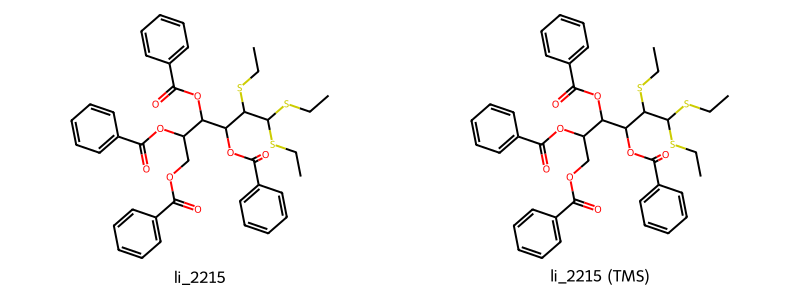

MASS:  746.204181304
(98, 2)
Highest intensity m/z:  105
Highest m/z value:  746
Lowest m/z value:  26


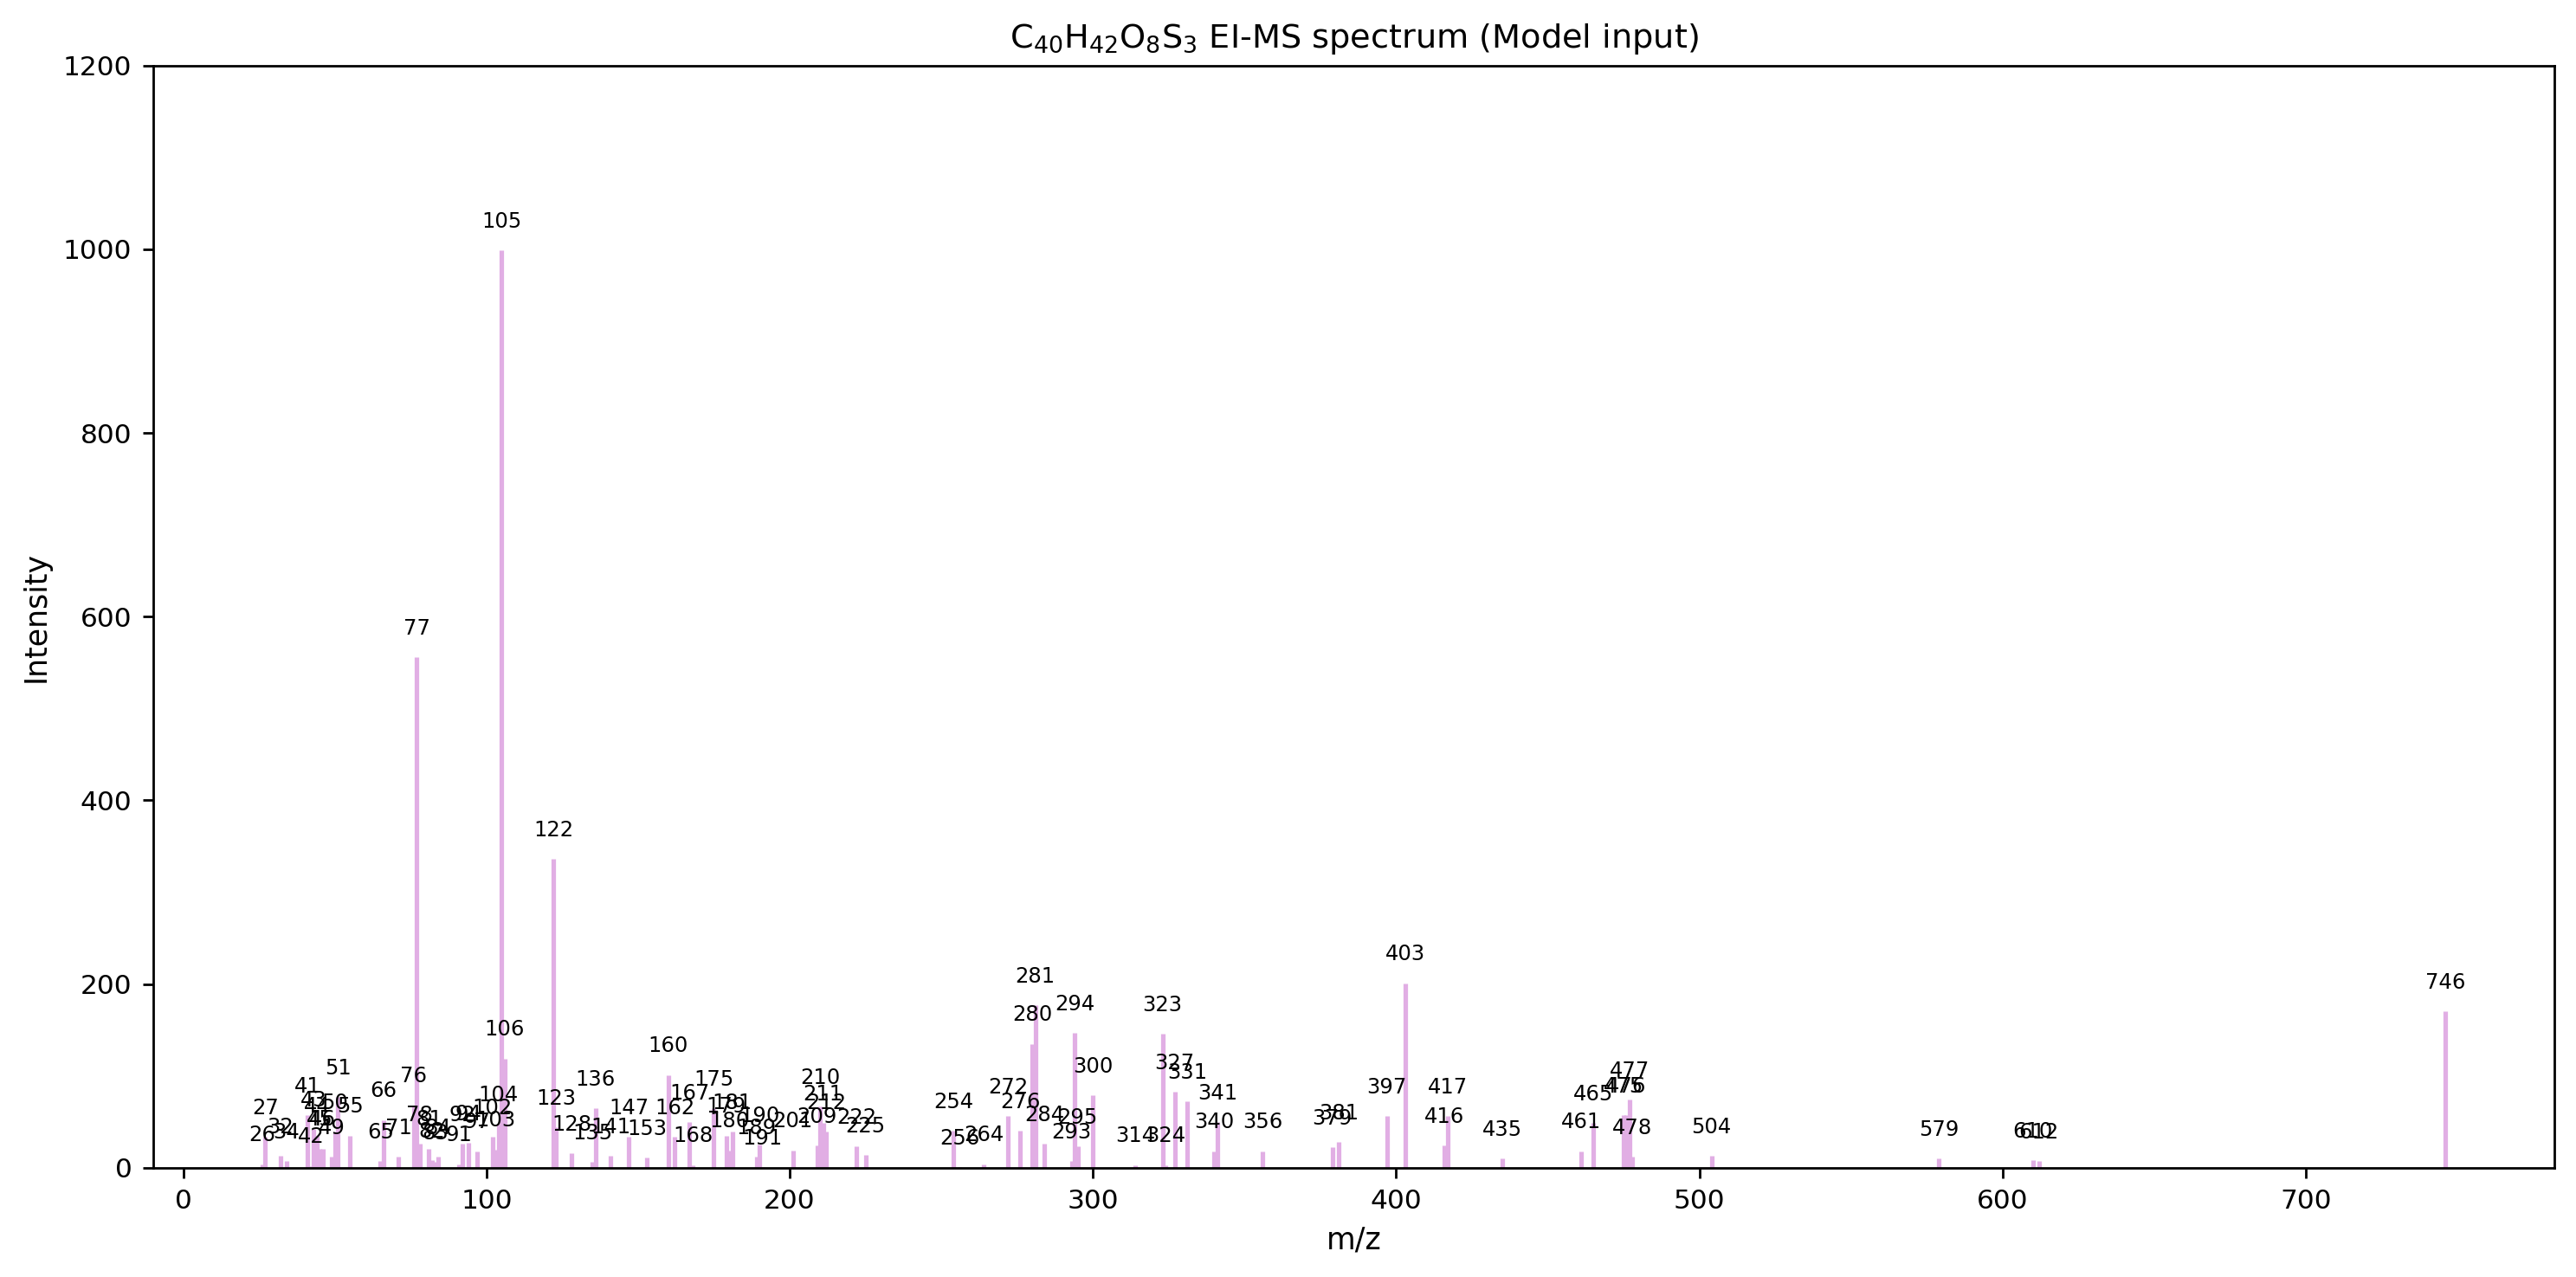

In [116]:
mol_name = 'li_2215'
view_molecule(
    mol_name = mol_name,
    mol1     = df_gecko_atmomaccs[df_gecko_atmomaccs['spec_y'] == mol_name]['smiles'].values[0],
    mol2     = df_gecko_atmomaccs[df_gecko_atmomaccs['spec_y'] == mol_name]['SMILES'].values[0],
    spec     = df_gecko_atmomaccs[df_gecko_atmomaccs['spec_y'] == mol_name]['spec_x'].values[0],
)

In [117]:
df_gecko_atmomaccs = df_gecko_atmomaccs.drop(columns='len_smiles')

In [118]:
train = df_gecko_atmomaccs[df_gecko_atmomaccs['split'] == 'train']
val = df_gecko_atmomaccs[df_gecko_atmomaccs['split'] == 'val']
val_inchi_key = val['inchikey']
train_inchikey = train['inchikey']
train_inchikey

9381      WSFSSNUMVMOOMR-UHFFFAOYSA-N
9382      CAMJPMYWRKKZNK-UHFFFAOYSA-N
9383      UJDBJZXDOVXPFV-UHFFFAOYSA-N
9384      RMULBIRLFFXIEL-UHFFFAOYSA-N
9385      NVYYGCURLZHQKD-UHFFFAOYSA-N
                     ...             
175533    QEHAKXBYUWFMNN-UHFFFAOYSA-N
175535    FBQPUINTQICKCK-UHFFFAOYSA-N
175536    UUQCECUWJAPTDH-UHFFFAOYSA-N
175537    QWVMJYNPWAQOLN-UHFFFAOYSA-N
175538    PONSWZNOCZZURN-UHFFFAOYSA-N
Name: inchikey, Length: 155918, dtype: object

In [119]:
train_mask = ~(train_inchikey == False)
val_mask =  ~(val_inchi_key == False)
train_mask

9381      True
9382      True
9383      True
9384      True
9385      True
          ... 
175533    True
175535    True
175536    True
175537    True
175538    True
Name: inchikey, Length: 155918, dtype: bool

In [120]:
test_mask = df_gecko_atmomaccs[df_gecko_atmomaccs['split'] == 'test']['inchikey']\
                            .apply(lambda x: x not in train_inchikey.values and \
                                             x not in val_inchi_key.values)

In [121]:
mask = pd.concat([train_mask, val_mask, test_mask])

In [122]:
df_gecko_atmomaccs = df_gecko_atmomaccs[mask]

C:\Users\kuuli\AppData\Local\Temp\ipykernel_27540\3919663274.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_gecko_atmomaccs = df_gecko_atmomaccs[mask]


In [123]:
df_gecko_atmomaccs = df_gecko_atmomaccs.drop_duplicates(subset='inchikey')

In [124]:
df_gecko_atmomaccs_labels = df_gecko_atmomaccs[['dataset', 'spec_y', 'ionization',
                                                'formula', 'smiles', 'inchikey', 'instrument']]
df_gecko_atmomaccs_labels = df_gecko_atmomaccs_labels.rename(columns={'spec_y': 'spec'})
df_gecko_atmomaccs_labels.to_csv('../data/gecko_atmomaccs/labels.tsv', sep='\t')
df_gecko_atmomaccs_labels

,dataset,spec,ionization,formula,smiles,inchikey,instrument
0,atmomaccs,ferraz-caetano_0,[M]+,C10H20,CCCCCCCCC=C,AFFLGGQVNFXPEV-UHFFFAOYSA-N,simulated
1,atmomaccs,ferraz-caetano_1,[M]+,C9H20,CCC(C)CC(C)(C)C,AFTPEBDOGXRMNQ-UHFFFAOYSA-N,simulated
2,atmomaccs,ferraz-caetano_2,[M]+,C9H20,CCCCCCCCC,BKIMMITUMNQMOS-UHFFFAOYSA-N,simulated
4,atmomaccs,ferraz-caetano_4,[M]+,C9H20,CC(C)CCC(C)(C)C,HHOSMYBYIHNXNO-UHFFFAOYSA-N,simulated
5,atmomaccs,ferraz-caetano_5,[M]+,C9H18,CCCCCCCC=C,JRZJOMJEPLMPRA-UHFFFAOYSA-N,simulated
...,...,...,...,...,...,...,...
175534,neims,gecko_166429,[M]+,C7H8N2O15,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,WYENNZRRQBYCFU-UHFFFAOYSA-N,simulated
175535,neims,gecko_166430,[M]+,C7H9NO11,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],FBQPUINTQICKCK-UHFFFAOYSA-N,simulated
175536,neims,gecko_166431,[M]+,C7H7NO11,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],UUQCECUWJAPTDH-UHFFFAOYSA-N,simulated
175537,neims,gecko_166432,[M]+,C6H6N2O14,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,QWVMJYNPWAQOLN-UHFFFAOYSA-N,simulated


In [125]:
df_gecko_atmomaccs_split = df_gecko_atmomaccs[['name', 'split']]
df_gecko_atmomaccs_split.to_csv('../data/gecko_atmomaccs/split.tsv', sep='\t', index=False)
df_gecko_atmomaccs_split

,name,split
0,ferraz-caetano_0,test
1,ferraz-caetano_1,test
2,ferraz-caetano_2,test
4,ferraz-caetano_4,test
5,ferraz-caetano_5,test
...,...,...
175534,gecko_166429,val
175535,gecko_166430,train
175536,gecko_166431,train
175537,gecko_166432,train


In [126]:
df_gecko_atmomaccs_spec_file = df_gecko_atmomaccs[['SMILES', 'spec_x']]
df_gecko_atmomaccs_spec_file = df_gecko_atmomaccs_spec_file.rename(columns={'spec_x': 'spec'})
df_gecko_atmomaccs_spec_file.to_pickle('../data/gecko_atmomaccs/spec_files/df_gecko_atmomaccs_3_9_22.pkl')
df_gecko_atmomaccs_spec_file

,SMILES,spec
0,CCCCCCCCC=C,"[[15, 1], [25, 17], [26, 103], [27, 474], [28,..."
1,CCC(C)CC(C)(C)C,"[[15, 36], [25, 3], [26, 34], [27, 198], [28, ..."
2,CCCCCCCCC,"[[14, 9], [15, 34], [25, 3], [26, 85], [27, 44..."
4,CC(C)CCC(C)(C)C,"[[14, 10], [15, 66], [25, 7], [26, 51], [27, 2..."
5,CCCCCCCC=C,"[[25, 10], [26, 96], [27, 445], [28, 211], [29..."
...,...,...
175534,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,"[[14, 70], [15, 145], [16, 82], [17, 31], [18,..."
175535,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 53], [15, 108], [16, 44], [17, 39], [18,..."
175536,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 54], [15, 123], [16, 54], [17, 45], [18,..."
175537,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,"[[14, 60], [15, 69], [16, 69], [26, 44], [27, ..."


In [127]:
df_gecko_atmomaccs

,SMILES,spec_x,name,Unnamed: 0,dataset,spec_y,ionization,formula,smiles,inchikey,instrument,split
0,CCCCCCCCC=C,"[[15, 1], [25, 17], [26, 103], [27, 474], [28,...",ferraz-caetano_0,0,atmomaccs,ferraz-caetano_0,[M]+,C10H20,CCCCCCCCC=C,AFFLGGQVNFXPEV-UHFFFAOYSA-N,simulated,test
1,CCC(C)CC(C)(C)C,"[[15, 36], [25, 3], [26, 34], [27, 198], [28, ...",ferraz-caetano_1,1,atmomaccs,ferraz-caetano_1,[M]+,C9H20,CCC(C)CC(C)(C)C,AFTPEBDOGXRMNQ-UHFFFAOYSA-N,simulated,test
2,CCCCCCCCC,"[[14, 9], [15, 34], [25, 3], [26, 85], [27, 44...",ferraz-caetano_2,2,atmomaccs,ferraz-caetano_2,[M]+,C9H20,CCCCCCCCC,BKIMMITUMNQMOS-UHFFFAOYSA-N,simulated,test
4,CC(C)CCC(C)(C)C,"[[14, 10], [15, 66], [25, 7], [26, 51], [27, 2...",ferraz-caetano_4,4,atmomaccs,ferraz-caetano_4,[M]+,C9H20,CC(C)CCC(C)(C)C,HHOSMYBYIHNXNO-UHFFFAOYSA-N,simulated,test
5,CCCCCCCC=C,"[[25, 10], [26, 96], [27, 445], [28, 211], [29...",ferraz-caetano_5,5,atmomaccs,ferraz-caetano_5,[M]+,C9H18,CCCCCCCC=C,JRZJOMJEPLMPRA-UHFFFAOYSA-N,simulated,test
...,...,...,...,...,...,...,...,...,...,...,...,...
175534,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,"[[14, 70], [15, 145], [16, 82], [17, 31], [18,...",gecko_166429,166153,neims,gecko_166429,[M]+,C7H8N2O15,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,WYENNZRRQBYCFU-UHFFFAOYSA-N,simulated,val
175535,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 53], [15, 108], [16, 44], [17, 39], [18,...",gecko_166430,166154,neims,gecko_166430,[M]+,C7H9NO11,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],FBQPUINTQICKCK-UHFFFAOYSA-N,simulated,train
175536,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 54], [15, 123], [16, 54], [17, 45], [18,...",gecko_166431,166155,neims,gecko_166431,[M]+,C7H7NO11,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],UUQCECUWJAPTDH-UHFFFAOYSA-N,simulated,train
175537,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,"[[14, 60], [15, 69], [16, 69], [26, 44], [27, ...",gecko_166432,166156,neims,gecko_166432,[M]+,C6H6N2O14,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,QWVMJYNPWAQOLN-UHFFFAOYSA-N,simulated,train


In [ ]:
from rdkit.Chem import Descriptors

FILTER_ATOMS = {'C', 'N', 'S', 'O', 'F', 'Cl', 'H', 'P', 'B', 'Br', 'I', 'Si'}
def filter(smiles_in: str):
    mol_in = Chem.MolFromSmiles(smiles_in)
    smi = Chem.MolToSmiles(mol_in, isomericSmiles=False) # remove stereochemistry information
    mol = Chem.MolFromSmiles(smi)
    mw = Descriptors.MolWt(mol)
    if mw >= 1500 or mw < 16.0 :
        print('mass constraint: ', mw, smi)
        return False
    '''
    for atom in mol.GetAtoms():
        if atom.GetFormalCharge() != 0:
            return False
    '''
    for atom in mol.GetAtoms():
        if atom.GetSymbol() not in FILTER_ATOMS:
            print('Found atom outside atom set: ', atom.GetSymbol(), smi)
            return False
        
    return True

In [131]:
df_filtered = df_gecko_atmomaccs['SMILES'].apply(filter)

In [133]:
df_filtered.sum()

0

In [ ]:
df_gecko_atmomaccs

,SMILES,spec_x,name,Unnamed: 0,dataset,spec_y,ionization,formula,smiles,inchikey,instrument,split
0,CCCCCCCCC=C,"[[15, 1], [25, 17], [26, 103], [27, 474], [28,...",ferraz-caetano_0,0,atmomaccs,ferraz-caetano_0,[M]+,C10H20,CCCCCCCCC=C,AFFLGGQVNFXPEV-UHFFFAOYSA-N,simulated,test
1,CCC(C)CC(C)(C)C,"[[15, 36], [25, 3], [26, 34], [27, 198], [28, ...",ferraz-caetano_1,1,atmomaccs,ferraz-caetano_1,[M]+,C9H20,CCC(C)CC(C)(C)C,AFTPEBDOGXRMNQ-UHFFFAOYSA-N,simulated,test
2,CCCCCCCCC,"[[14, 9], [15, 34], [25, 3], [26, 85], [27, 44...",ferraz-caetano_2,2,atmomaccs,ferraz-caetano_2,[M]+,C9H20,CCCCCCCCC,BKIMMITUMNQMOS-UHFFFAOYSA-N,simulated,test
4,CC(C)CCC(C)(C)C,"[[14, 10], [15, 66], [25, 7], [26, 51], [27, 2...",ferraz-caetano_4,4,atmomaccs,ferraz-caetano_4,[M]+,C9H20,CC(C)CCC(C)(C)C,HHOSMYBYIHNXNO-UHFFFAOYSA-N,simulated,test
5,CCCCCCCC=C,"[[25, 10], [26, 96], [27, 445], [28, 211], [29...",ferraz-caetano_5,5,atmomaccs,ferraz-caetano_5,[M]+,C9H18,CCCCCCCC=C,JRZJOMJEPLMPRA-UHFFFAOYSA-N,simulated,test
...,...,...,...,...,...,...,...,...,...,...,...,...
175534,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,"[[14, 70], [15, 145], [16, 82], [17, 31], [18,...",gecko_166429,166153,neims,gecko_166429,[M]+,C7H8N2O15,CC1(O)C(C(O)C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO...,WYENNZRRQBYCFU-UHFFFAOYSA-N,simulated,val
175535,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 53], [15, 108], [16, 44], [17, 39], [18,...",gecko_166430,166154,neims,gecko_166430,[M]+,C7H9NO11,CC1(O)C(C(O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],FBQPUINTQICKCK-UHFFFAOYSA-N,simulated,train
175536,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],"[[14, 54], [15, 123], [16, 54], [17, 45], [18,...",gecko_166431,166155,neims,gecko_166431,[M]+,C7H7NO11,CC1(O)C(C(=O)C=O)OOC1(O)C(=O)OO[N+](=O)[O-],UUQCECUWJAPTDH-UHFFFAOYSA-N,simulated,train
175537,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,"[[14, 60], [15, 69], [16, 69], [26, 44], [27, ...",gecko_166432,166156,neims,gecko_166432,[M]+,C6H6N2O14,CC1(O)C(C(=O)OO[N+](=O)[O-])OOC1(O)C(=O)OO[N+]...,QWVMJYNPWAQOLN-UHFFFAOYSA-N,simulated,train


In [137]:
from rdkit import Chem
import pandas as pd

def heavy_atom_count(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return sum(1 for atom in mol.GetAtoms() if atom.GetAtomicNum() != 1)

# filter training set
df_train = df_gecko_atmomaccs[df_gecko_atmomaccs['name'].str.startswith('gecko_')]
df_test = df_gecko_atmomaccs[~df_gecko_atmomaccs['name'].str.startswith('gecko_')]
# compute heavy atom counts
df_train['N_heavy'] = df_train['SMILES'].apply(heavy_atom_count)
df_test['N_heavy'] = df_test['SMILES'].apply(heavy_atom_count)

# basic stats
print("Min (Train):", df_train['N_heavy'].min())
print("Max (Train):", df_train['N_heavy'].max())
print("Mean (Train):", df_train['N_heavy'].mean())
print("Min (Test):", df_test['N_heavy'].min())
print("Max (Test):", df_test['N_heavy'].max())
print("Mean (Test):", df_test['N_heavy'].mean())


C:\Users\kuuli\AppData\Local\Temp\ipykernel_27540\213104791.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['N_heavy'] = df_train['SMILES'].apply(heavy_atom_count)


Min (Train): 2
Max (Train): 28
Mean (Train): 18.168532360765056
Min (Test): 1
Max (Test): 82
Mean (Test): 12.394642322657887


C:\Users\kuuli\AppData\Local\Temp\ipykernel_27540\213104791.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['N_heavy'] = df_test['SMILES'].apply(heavy_atom_count)


In [143]:
print('(df_test[\'N_heavy\'] > 28).mean(): ', (df_test['N_heavy'] > 28).mean())

(df_test['N_heavy'] > 28).mean():  0.020502843460041904
